In [28]:
import numpy as np
import astropy.units as u
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from importlib import reload
from astropy.io import fits
import ray
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle

from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc.imshows import imshow1, imshow2, imshow3, imshow
from scoob_llowfsc import utils
import scoob_llowfsc.scoob_model as scoobm

wfe_data = utils.load_pickle('sim-data/example_wfe_data.pkl')
iefc_data = utils.load_pickle('sim-data/example_iefc_data.pkl')
dh_command = iefc_data['commands'][-1]


Oversampling > 2x suggested for reliable results in Fresnel propagation.


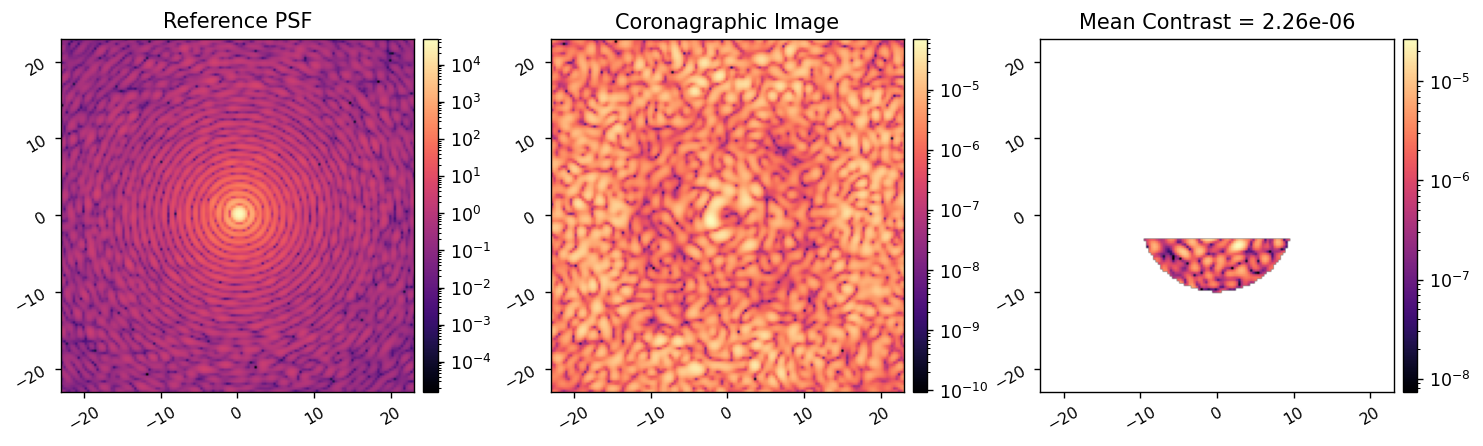

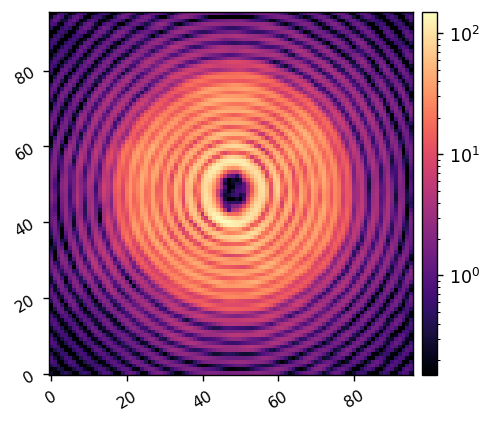

In [29]:
reload(scoobm)
reload(utils)

M = scoobm.single(
    dm_ref=wfe_data['DM_FLAT'],
)
M.PREFPM_AMP = wfe_data['PREFPM_AMP']
M.PREFPM_OPD = wfe_data['PREFPM_OPD']

M.POSTFPM_AMP = wfe_data['POSTFPM_AMP']
M.POSTFPM_OPD = wfe_data['POSTFPM_OPD']

M.RLS_AMP = wfe_data['RLS_AMP']
M.RLS_OPD = wfe_data['RLS_OPD']

# M.ncamsci = 256
# M.ncamlo = 96
# M.llowfsc_defocus = 2.75e-3

iwa = 3
owa = 10
control_mask = utils.create_annular_focal_plane_mask(
    M.ncamsci, 
    M.camsci_pxscl_lamD, 
    iwa, 
    owa,  
    edge=iwa,
    rotation=90,
)

M.use_vortex = 0
ref_psf = M.snap_camsci()
M.Imax_ref = xp.max(ref_psf)

M.use_vortex = 1
camsci_im0 = M.snap_camsci()
mean_contrast = xp.mean(camsci_im0[control_mask])

imshow3(
    ref_psf, camsci_im0, camsci_im0*control_mask,
    'Reference PSF', 'Coronagraphic Image', f'Mean Contrast = {mean_contrast:.2e}', 
    pxscl=M.camsci_pxscl_lamDc,
    lognorm=1, 
)

camlo_im0 = M.snap_camlo()
imshow1(camlo_im0, lognorm=1, vmin=xp.max(camlo_im0)/1e3)

In [3]:
wavelength_c = 633e-9
bw = 0.1
Nwaves = 5
waves = np.linspace((1-bw/2)*wavelength_c, (1+bw/2)*wavelength_c, Nwaves)
print(Nwaves)

ray_single = ray.remote(scoobm.single)

ACTORS = []
for i in range(Nwaves):
    params = {
        'wavelength':waves[i],
        'dm_ref':wfe_data['DM_FLAT'],
    }
    ACTORS.append(ray_single.options(num_cpus=4, num_gpus=1/2).remote(**params))



5


2025-03-14 20:00:16,768	INFO worker.py:1832 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 


(pid=125506) /home/kianmilani/miniconda3/envs/km311env/lib/python3.11/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
(pid=125506)   cupy._util.experimental('cupyx.jit.rawkernel')
(single pid=125506) Oversampling > 2x suggested for reliable results in Fresnel propagation.
(pid=125505) /home/kianmilani/miniconda3/envs/km311env/lib/python3.11/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future. [repeated 4x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(pid=125505)   cupy._util.experimental('cupyx.jit.rawkernel') [repeated 4x across cluster]


1


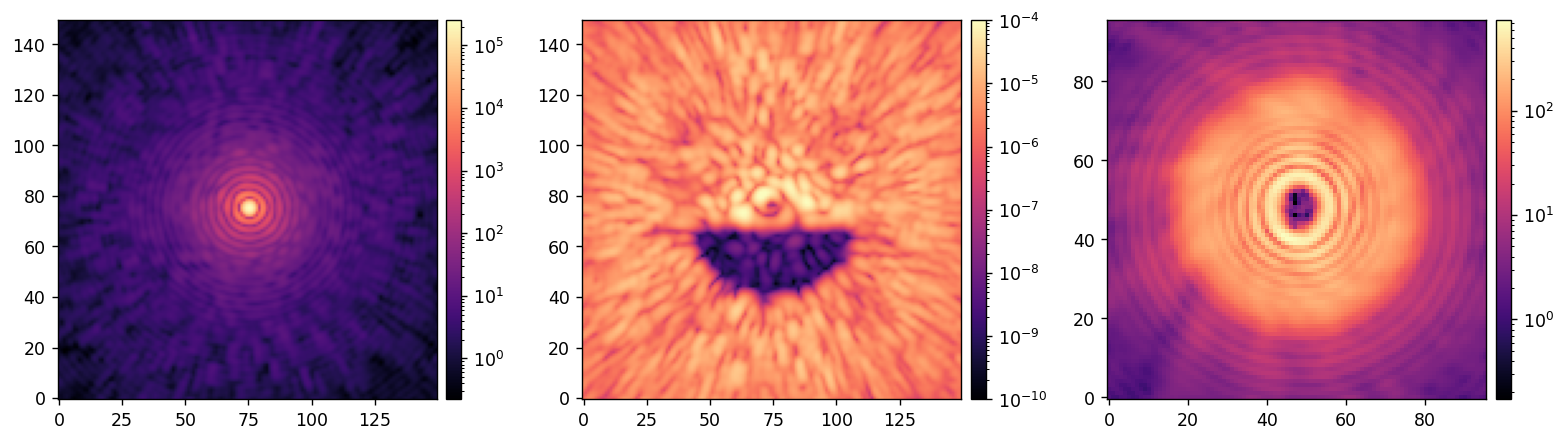

In [41]:
reload(scoobm)
M = scoobm.parallel(ACTORS)
M.reset_dm()
M.zero_fsm()

M.set_actor_attr('PREFPM_AMP', wfe_data['PREFPM_AMP'])
M.set_actor_attr('PREFPM_OPD', wfe_data['PREFPM_OPD'])

M.set_actor_attr('POSTFPM_AMP', wfe_data['POSTFPM_AMP'])
M.set_actor_attr('POSTFPM_OPD', wfe_data['POSTFPM_OPD'])

M.set_actor_attr('RLS_AMP', wfe_data['RLS_AMP'])
M.set_actor_attr('RLS_OPD', wfe_data['RLS_OPD'])

M.set_actor_attr('use_vortex', False)
ref_psf = M.snap_camsci()
M.Imax_ref = xp.max(ref_psf)

M.add_dm(dh_command)

M.add_fsm( np.array([0, 0, 0]))
M.set_actor_attr('use_vortex', True)
coro_im = M.snap_camsci()

camlo_im = M.snap_camlo()

imshow(
    [ref_psf, coro_im, camlo_im],
    norms=[LogNorm(), LogNorm(1e-10, 1e-4), LogNorm()],
    cmaps=['magma']*3,
    wspace=0.3,
)
